In [4]:
# Cell 1: Imports & Utilities

import os, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Device and reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

# sinusoidal time embedding
def sinusoidal_time_embedding(timesteps, dim):
    """
    timesteps: (B,) int64
    returns: (B, dim)
    """
    device_ = timesteps.device
    half_dim = dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=device_) * -emb)
    emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class TimeMLP(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out),
        )

    def forward(self, t_emb):
        return self.net(t_emb)


Using device: cuda


In [5]:
# Cell 2: UNet Model

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = TimeMLP(time_emb_dim, out_ch)
        self.act = nn.SiLU()
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.norm2 = nn.BatchNorm2d(out_ch)

    def forward(self, x, t_emb):
        # t_emb: (B, time_emb_dim)
        h = self.conv1(x)

        # incorporate time embedding
        temb = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + temb
        h = self.act(self.norm1(h))

        h = self.conv2(h)
        h = self.act(self.norm2(h))
        return h

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        h = self.block(x, t_emb)
        p = self.pool(h)
        return h, p

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        return self.block(x, t_emb)

class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=128, time_emb_dim=128):
        super().__init__()

        # global time embedding
        self.time_mlp_input_dim = time_emb_dim
        self.time_mlp = TimeMLP(time_emb_dim, time_emb_dim)

        # encoder
        self.down1 = DownBlock(img_channels, base_channels, time_emb_dim)
        self.down2 = DownBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down3 = DownBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        # bottleneck
        self.mid = ConvBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        # decoder
        self.up3 = UpBlock(base_channels * 4 + base_channels * 4, base_channels * 2, time_emb_dim)
        self.up2 = UpBlock(base_channels * 2 + base_channels * 2, base_channels, time_emb_dim)
        self.up1 = UpBlock(base_channels + base_channels, base_channels, time_emb_dim)

        # output
        self.out_conv = nn.Conv2d(base_channels, img_channels, kernel_size=1)

    def forward(self, x, t):
        # t: (B,)
        t_emb = sinusoidal_time_embedding(t, self.time_mlp_input_dim)
        t_emb = self.time_mlp(t_emb)

        s1, p1 = self.down1(x, t_emb)
        s2, p2 = self.down2(p1, t_emb)
        s3, p3 = self.down3(p2, t_emb)

        m = self.mid(p3, t_emb)

        u3 = self.up3(m, s3, t_emb)
        u2 = self.up2(u3, s2, t_emb)
        u1 = self.up1(u2, s1, t_emb)

        out = self.out_conv(u1)
        return out


In [6]:
# Cell 3: DDPM Class

class DDPM(nn.Module):
    def __init__(self, model, T=1000, beta_start=1e-4, beta_end=2e-2, device=device):
        super().__init__()
        self.model = model
        self.T = T
        self.device = device

        # define the noise schedule
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def q_sample(self, x0, t, noise=None):
        """
        Diffuse the data (forward process): q(x_t | x_0)
        """
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x0 + sqrt_om * noise

    def p_losses(self, x0, t, noise=None):
        """
        Training loss: predict the added noise.
        """
        if noise is None:
            noise = torch.randn_like(x0)
        x_noisy = self.q_sample(x0, t, noise)
        noise_pred = self.model(x_noisy, t)
        return F.mse_loss(noise_pred, noise)

    @torch.no_grad()
    def p_sample(self, x_t, t):
        """
        Single reverse step p(x_{t-1} | x_t)
        """
        betas_t = self.betas[t].view(-1, 1, 1, 1)
        sqrt_one_minus_ac_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_recip_alphas_t = (1.0 / torch.sqrt(self.alphas[t])).view(-1, 1, 1, 1)

        eps_theta = self.model(x_t, t)
        model_mean = sqrt_recip_alphas_t * (x_t - betas_t / sqrt_one_minus_ac_t * eps_theta)

        if (t == 0).all():
            return model_mean
        else:
            noise = torch.randn_like(x_t)
            var = self.posterior_variance[t].view(-1, 1, 1, 1)
            return model_mean + torch.sqrt(var) * noise

    @torch.no_grad()
    def sample(self, img_shape, n_samples):
        """
        Generate samples from pure noise.
        """
        self.model.eval()
        x_t = torch.randn(n_samples, *img_shape).to(self.device)
        for i in reversed(range(self.T)):
            t = torch.full((n_samples,), i, device=self.device, dtype=torch.long)
            x_t = self.p_sample(x_t, t)
        return x_t


Files already downloaded and verified
Number of batches: 391


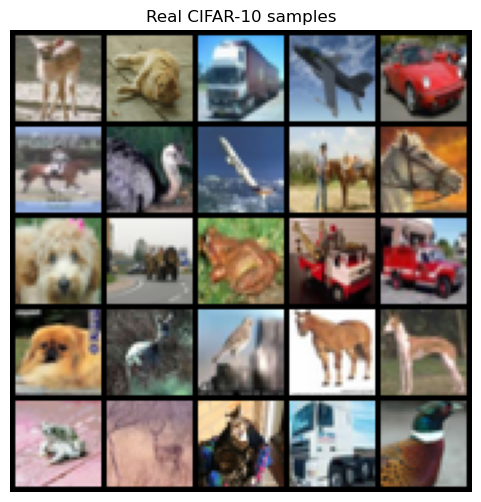

In [7]:
# Cell 4: DataLoader + quick visualization of real CIFAR-10 images

def get_dataloader(batch_size=128, data_root="./data"):
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),  # map to [-1,1]
    ])
    train_ds = datasets.CIFAR10(
        root=data_root,
        train=True,
        download=True,
        transform=transform
    )
    # num_workers=0 to avoid multiprocessing issues on clusters
    loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )
    return loader

batch_size = 128
dataloader = get_dataloader(batch_size=batch_size)

print("Number of batches:", len(dataloader))

# Show some real CIFAR-10 images for the report
real_batch, real_labels = next(iter(dataloader))
# denormalize to [0,1] just for plotting
real_vis = (real_batch[:25] * 0.5 + 0.5).clamp(0,1)

grid = utils.make_grid(real_vis, nrow=5)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
plt.title("Real CIFAR-10 samples")
plt.axis("off")
plt.show()


In [8]:
# Cell 5: FID Calculation using ResNet-18

import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import resnet18, ResNet18_Weights

fid_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretrained ResNet-18 on ImageNet
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()  # remove final classifier head
resnet.to(fid_device)
resnet.eval()

@torch.no_grad()
def get_activations(images, model, device=fid_device, batch_size=64):
    """
    images: (N, C, H, W) in [0,1]
    returns: (N, D) features
    """
    model.eval()
    activations = []
    n = images.shape[0]
    for i in range(0, n, batch_size):
        batch = images[i:i+batch_size].to(device)
        # if grayscale, repeat channels
        if batch.shape[1] == 1:
            batch = batch.repeat(1,3,1,1)
        act = model(batch)
        activations.append(act.cpu().numpy())
    activations = np.concatenate(activations, axis=0)
    return activations

def calculate_fid(real_images, fake_images, model, device=fid_device):
    """
    real_images, fake_images in [-1,1], shape (N,3,32,32)
    We internally map them to [0,1] for ResNet.
    """
    # map to [0,1]
    real_images = (real_images + 1.0) / 2.0
    fake_images = (fake_images + 1.0) / 2.0

    real_images = real_images.clamp(0,1)
    fake_images = fake_images.clamp(0,1)

    act1 = get_activations(real_images, model, device=device)
    act2 = get_activations(fake_images, model, device=device)

    mu1, sigma1 = np.mean(act1, axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = np.mean(act2, axis=0), np.cov(act2, rowvar=False)

    ssdiff = np.sum((mu1 - mu2)**2)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2*covmean)
    return float(fid)


In [9]:
# Cell 6: Training Loop (with FID, best FID, and metrics stored)

img_shape = (3, 32, 32)
epochs = 50        # you can reduce to test quickly
lr = 2e-4
T = 1000

model = UNet(img_channels=3, base_channels=128, time_emb_dim=128).to(device)
ddpm = DDPM(model, T=T, beta_start=1e-4, beta_end=2e-2, device=device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

all_losses = []
all_fids = []

best_fid = float("inf")
best_epoch = -1

# Fix one real batch for FID comparison (avoids creating new DataLoaders)
fixed_real_batch, _ = next(iter(dataloader))
fixed_real_batch = fixed_real_batch[:64].to(device)  # in [-1,1]

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        x = x.to(device)

        optimizer.zero_grad()
        b = x.size(0)
        t = torch.randint(0, T, (b,), device=device).long()

        loss = ddpm.p_losses(x, t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    all_losses.append(avg_loss)

    # Sampling & FID every epoch
    with torch.no_grad():
        samples = ddpm.sample(img_shape, n_samples=64).to(device)
        # samples are already in [-1,1] (due to tanh-like behavior of network + training)
        fid = calculate_fid(fixed_real_batch, samples, resnet, device=fid_device)
        all_fids.append(fid)

    if fid < best_fid:
        best_fid = fid
        best_epoch = epoch + 1
        # save best model weights
        torch.save(model.state_dict(), "best_ddpm_cifar10.pth")

    print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | FID: {fid:.2f} | Best FID so far: {best_fid:.2f} (epoch {best_epoch})")

print("\nTraining finished.")
print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")
avg_fid = sum(all_fids) / len(all_fids)
print(f"Average FID over all epochs: {avg_fid:.4f}")


Epoch 1/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.0784 | FID: 82.71 | Best FID so far: 82.71 (epoch 1)


Epoch 2/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 002 | Loss: 0.0481 | FID: 96.94 | Best FID so far: 82.71 (epoch 1)


Epoch 3/50:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 048 | Loss: 0.0329 | FID: 48.51 | Best FID so far: 41.76 (epoch 35)


Epoch 49/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 049 | Loss: 0.0325 | FID: 57.22 | Best FID so far: 41.76 (epoch 35)


Epoch 50/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 050 | Loss: 0.0326 | FID: 51.94 | Best FID so far: 41.76 (epoch 35)

Training finished.
Best FID: 41.7626 at epoch 35
Average FID over all epochs: 65.7563


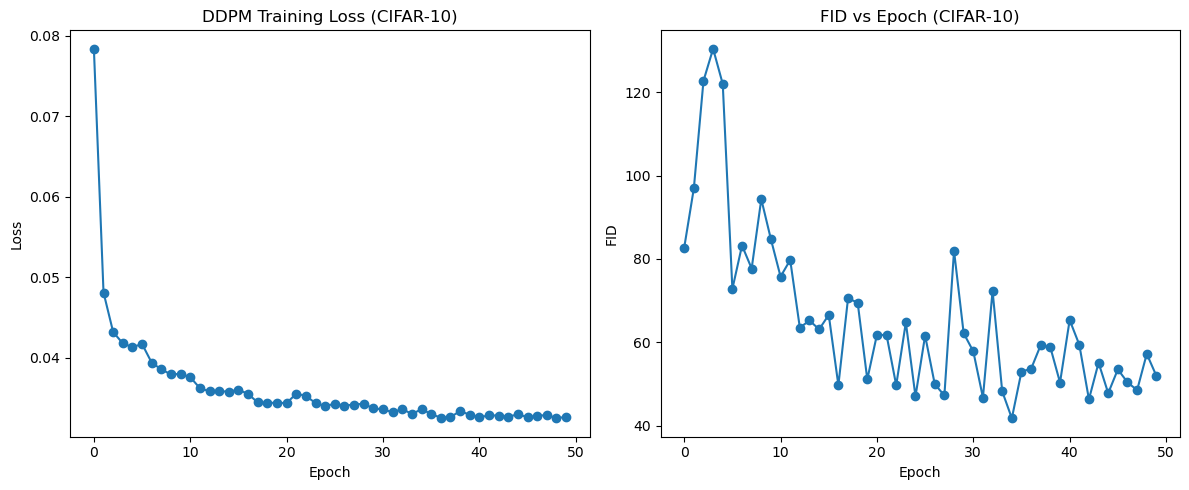

Best FID: 41.7626 at epoch 35
Average FID over all epochs: 65.7563


In [10]:
# Cell 7: Plots for Report – Loss curve & FID curve

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(all_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Training Loss (CIFAR-10)")

# FID plot
plt.subplot(1,2,2)
plt.plot(all_fids, marker="o")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID vs Epoch (CIFAR-10)")

plt.tight_layout()
plt.show()

print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")
print(f"Average FID over all epochs: {avg_fid:.4f}")


/local_scratch/slurm.7608509/ipykernel_283317/3419866686.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_ddpm_cifar10.pth", map_lo

Loaded best model weights.


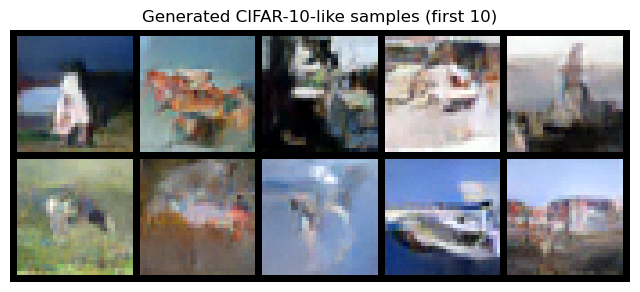

In [14]:
# Cell 8: Show generated samples (for "10 best pictures" type of requirement)

# Load best model weights if you want to sample from the best epoch
if os.path.exists("best_ddpm_cifar10.pth"):
    model.load_state_dict(torch.load("best_ddpm_cifar10.pth", map_location=device))
    print("Loaded best model weights.")

model.eval()

with torch.no_grad():
    # sample more than 10 and just show first 10
    n_samples = 25
    samples = ddpm.sample(img_shape, n_samples=n_samples).cpu()

# map from [-1,1] to [0,1] for visualization
samples_vis = (samples.clamp(-1,1) + 1) / 2.0

grid = utils.make_grid(samples_vis[:10], nrow=5)
plt.figure(figsize=(8,4))
plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
plt.title("Generated CIFAR-10-like samples (first 10)")
plt.axis("off")
plt.show()


In [15]:
# Cell 9 (optional): Save a grid of 10 generated images to file for the report

save_dir = "generated_results"
os.makedirs(save_dir, exist_ok=True)

grid_path = os.path.join(save_dir, "top10_generated_grid.png")
utils.save_image(samples_vis[:10], grid_path, nrow=5)

print(f"Saved a 10-image grid to: {grid_path}")


Saved a 10-image grid to: generated_results/top10_generated_grid.png
